In [1]:
from src.analysis.regression_models import create_regression_runner
from src.analysis.engine import AnalysisEnvironment
from src.utils import interactive_regression_results_selector
import pandas as pd
from scipy.stats.mstats import winsorize



In [2]:
# Setup
env = AnalysisEnvironment(active_analysis='barter_deals')

# Load everything
final_df, og_df = env.load_data(raw_filename='BARTER_DEALS_CLEAN.parquet')
pm, prompt_map = env.load_prompts(prompt_subfolder='sandbox/BARTER_DEALS')

Loading files for analysis barter_deals
🐢 Running full processing pipeline...
Finished loading experiment data
Found 0 experimental trials contaminated by garbage output.
Found 2 different scale sizes: [np.int64(4), np.int64(5)]
  Processed 1000 rows with scale_size=5
  Processed 8120 rows with scale_size=4
Computing entropy for 2 different scale sizes: [np.int64(4), np.int64(5)]
  Processed 1000 rows with scale_size=5
  Processed 8120 rows with scale_size=4
PromptManager initialized with folder: ../prompts/PromptSuites/sandbox/BARTER_DEALS
Scanning 3 suites from ../prompts/PromptSuites/sandbox/BARTER_DEALS...
Loaded 3 PromptSuites


# Data cleaning

We consider a number of filtering approaches. Content type is a strong predictor, but some have too few observations to obtain a stable parameter estimate. E.g., Finance and Photography have only 15 and 5 observations respectively, and with a coefficient of $\approx -23$, in a log model their coefficient is effectively zero. Since they have near-zero applications in the entire dataset, we waste degrees of freedom trying to fit tiny noisy groups. We suggest a to filter category size to only include ones that have "signal" in their observations. 


- Remove obs with 0 applications

There are 'dead deals', where they have zero applications but are well-written. They have never been online at all, artificially inflating the zero-category with structural error (good deals that have no applications, while we know that good deals will get more applications). We remove the deals with 0 applications $n=865$, while retaining sufficient number of deals with 0 applications after 7 days $n=1650$


- Deals with a significant number of applications but no applications after 7 days

Some deals have no applications after 7 days, but a high total applications count. I observed that often these are good deals, but have no applications after 7 days for different reasons. The apps after 7 days variable is created using a specific starting date within in the database, but there is no 'clean' variable that measures when it actually went live. It could have been put live weeks after being created, so it garnered applications later than the initial seven-day period. Therefore, we remove observations where this difference is too big, indicating that the applications after 7 days is not representative of its actual performance. 


- Remove archived deals

We remove archived deals because they likely have never been put live 

- Average duplicate deal texts

We have deals that are identical, but with different numbers of applications. We take the average to remove some of the noise. 

- Partner filters

We remove $partner\_id=85$ because they are deals posted by Barter, they are part of Barter campaigns not the regular partner deals. 

- winsorizing (cap the variable at the 9xth percentile)

In count data (especially social media or job posts), "viral" outliers can distort the mean and variance. A single post with 1,000 applications (due to luck) adds massive noise.


In [3]:
def filter_low_n_categories(df, MIN_OBSERVATIONS=50):# 1. Define a minimum threshold (e.g., 50 observations)

    # 2. Count observations per category
    counts = df['first_content_type'].value_counts()

    # 3. Identify valid categories
    valid_categories = counts[counts >= MIN_OBSERVATIONS].index.tolist()

    print(f"Keeping {len(valid_categories)} categories: {valid_categories}")
    print(f"Dropping: {counts[counts < MIN_OBSERVATIONS].index.tolist()}")

    # 4. Filter the dataframe
    # Only keep rows where the content type is in our valid list
    return df[df['first_content_type'].isin(valid_categories)].copy()

 

def data_cleaning(ratings_df, MIN_CATEGORY_OBSERVATIONS = 50, PARTNER_IDS_TO_REMOVE = [85]):
    df = ratings_df.copy()

    # Remove categories with low number of observations (important if it is added as predictor)
    df = filter_low_n_categories(df, MIN_CATEGORY_OBSERVATIONS)

    # Remove obs with 0 applications
    df = df[df['applicants_applications_count'] > 0]

    # Deals with a significant number of applications but no applications after 7 days
    df = df[(df['applicants_applications_count'] > 10) & (df['apps_after_7_days'] > 0)]

    # Remove archived deals (never have been put live)
    df = df[df['status'] != 'archived']

    # Filter specific partners
    df = df[~df.partner_id.isin(PARTNER_IDS_TO_REMOVE)]

    # Clip the top 1% of outliers to reduce variance from 'viral luck'
    df['apps_after_7_days_clean'] = winsorize(df['apps_after_7_days'], limits=[0, 0.01])

    return df 



In [4]:
model_df = data_cleaning(final_df)
model_df

Keeping 18 categories: ['Activities', 'Food', 'Experiences', 'UGC', 'Beauty', 'Fashion', 'Luxury', 'Cooking', 'Lifestyle', 'Drinks', 'Sport', 'Travel', 'Entertainment', 'Mom', 'Tech', 'Animals', 'Music', 'Cars']
Dropping: ['Finance', 'Gaming', 'Vegan', 'Photography', 'Nightlife', 'Movie']


,applicants_applications_count,content_types,deal_id,main_image,min_social_media_followers,deal_tags,live_since,created_at,updated_at,deleted_at,...,constrained_tokens,sorted_tokens,sorted_logits,mean_rating,mode_rating,scale_size,entropy,normalized_entropy,first_content_type,apps_after_7_days_clean
10,23,"[{'id': 29, 'name': 'UGC', 'slug': 'Film-Strip'}]",019689e2-bfb5-00c8-6485-23352d64b0e5,uploads/deals/019689e2-c06c-ffff-baf0-c7e9decd...,5000,None,2025-03-04 11:46:18.176627,2025-03-04 11:46:18.176627,2025-05-01 03:27:41.316646,NaT,...,"[1, 2, 3, 4, 5]","[1, 2, 3, 4, 5]","[[18.20315933227539, 23.730012893676758, 34.79...",3.999999,4.0,5,0.000012,0.000008,UGC,13
11,23,"[{'id': 29, 'name': 'UGC', 'slug': 'Film-Strip'}]",019689e2-bfb5-00c8-6485-23352d64b0e5,uploads/deals/019689e2-c06c-ffff-baf0-c7e9decd...,5000,None,2025-03-04 11:46:18.176627,2025-03-04 11:46:18.176627,2025-05-01 03:27:41.316646,NaT,...,"[1, 2, 3, 4]","[1, 2, 3, 4]","[[36.464111328125, 39.859580993652344, 37.0575...",2.024832,2.0,4,0.349530,0.252133,UGC,13
12,23,"[{'id': 29, 'name': 'UGC', 'slug': 'Film-Strip'}]",019689e2-bfb5-00c8-6485-23352d64b0e5,uploads/deals/019689e2-c06c-ffff-baf0-c7e9decd...,5000,None,2025-03-04 11:46:18.176627,2025-03-04 11:46:18.176627,2025-05-01 03:27:41.316646,NaT,...,"[1, 2, 3, 4]","[1, 2, 3, 4]","[[29.428558349609375, 38.03034210205078, 35.69...",2.088039,2.0,4,0.300018,0.216417,UGC,13
13,23,"[{'id': 29, 'name': 'UGC', 'slug': 'Film-Strip'}]",019689e2-bfb5-00c8-6485-23352d64b0e5,uploads/deals/019689e2-c06c-ffff-baf0-c7e9decd...,5000,None,2025-03-04 11:46:18.176627,2025-03-04 11:46:18.176627,2025-05-01 03:27:41.316646,NaT,...,"[1, 2, 3, 4]","[1, 2, 3, 4]","[[27.727567672729492, 36.63376998901367, 36.88...",2.563088,3.0,4,0.685918,0.494786,UGC,13
14,23,"[{'id': 29, 'name': 'UGC', 'slug': 'Film-Strip'}]",019689e2-bfb5-00c8-6485-23352d64b0e5,uploads/deals/019689e2-c06c-ffff-baf0-c7e9decd...,5000,None,2025-03-04 11:46:18.176627,2025-03-04 11:46:18.176627,2025-05-01 03:27:41.316646,NaT,...,"[1, 2, 3, 4]","[1, 2, 3, 4]","[[31.06571388244629, 39.034000396728516, 37.36...",2.158734,2.0,4,0.440704,0.317901,UGC,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9111,14,"[{'id': 23, 'name': 'Food', 'slug': 'Pizza'}]",019689e5-7588-00c8-cfda-f43953c78d10,uploads/deals/019689e5-771b-ffff-87ec-29f89bae...,5000,None,2024-10-17 19:03:20.768040,2024-10-17 19:03:20.768040,2025-10-28 10:52:56.258489,NaT,...,"[1, 2, 3, 4]","[1, 2, 3, 4]","[[48.5636100769043, 44.389041900634766, 35.792...",1.015154,1.0,4,0.078543,0.056657,Food,1
9112,14,"[{'id': 23, 'name': 'Food', 'slug': 'Pizza'}]",019689e5-7588-00c8-cfda-f43953c78d10,uploads/deals/019689e5-771b-ffff-87ec-29f89bae...,5000,None,2024-10-17 19:03:20.768040,2024-10-17 19:03:20.768040,2025-10-28 10:52:56.258489,NaT,...,"[1, 2, 3, 4]","[1, 2, 3, 4]","[[48.97531509399414, 43.054725646972656, 35.34...",1.002679,1.0,4,0.018544,0.013376,Food,1
9116,13,"[{'id': 23, 'name': 'Food', 'slug': 'Pizza'}]",019689e5-75fd-00c8-b1bc-3c3f30ada52b,uploads/deals/019689e5-77e4-ffff-da0c-8802ffe9...,5000,None,2024-07-19 08:15:58.416224,2024-07-19 08:15:58.416224,2025-10-28 10:53:44.105833,NaT,...,"[1, 2, 3, 4]","[1, 2, 3, 4]","[[26.81580924987793, 34.45259475708008, 31.429...",2.045902,2.0,4,0.191655,0.138250,Food,10
9117,13,"[{'id': 23, 'name': 'Food', 'slug': 'Pizza'}]",019689e5-75fd-00c8-b1bc-3c3f30ada52b,uploads/deals/019689e5-77e4-ffff-da0c-8802ffe9...,5000,None,2024-07-19 08:15:58.416224,2024-07-19 08:15:58.416224,2025-10-28 10:53:44.105833,NaT,...,"[1, 2, 3, 4]","[1, 2, 3, 4]","[[23.850685119628906, 31.932941436767578, 34.3...",2.917639,3.0,4,0.292160,0.210749,Food,10


In [5]:
model_df.deal_text.value_counts()

deal_text
Vibecreation (VIBE) isn’t just a brand—it’s an experience. Founded in 2024 by a Molecular Scientist alongside two visionary Architects as Creative Directors, we blend science and design to create something truly unique. Right now, we’re offering exclusive promotional opportunities—select partners will receive free items in exchange for strategic exposure. If you see the potential in collaborating with an innovative, boundary-pushing brand, let’s talk.                                                                                                                                                                                                                                                                                                                                                                18
\nMet deze barterdeal kan jij je Medium Poké of burrito naar keuze ophalen bij de counter. Op vertoon van deze Barter kan jij een gratis burrito of poke ophalen!                   

# Models

In [6]:
# 2. Define Variables (Move these to your config.yaml later!)
GROUPS = ['model_name', 'prompt_id']

###
TARGET = 'apps_after_7_days'
TARGET = 'apps_after_7_days_clean'

# TARGET = 'apps_after_7_days_OLD'
# TARGET = 'applicants_applications_count'

###
# Categorical variables
CATS = []  # Empty as per your "LLM Eval only" test
CATS = ['first_content_type']
# CATS = ['deal_type', 'first_content_type', 'social_requirement_type_id']


### 
# Binary variables
BINS = []
# BINS = ['accepts_international']  # Already 0/1 or T/F

###
# LLM evaluation variable
SCORE_VAR = 'mean_rating'

###
# Column for Clustered standard errors
CLUSTER_COL = 'partner_id'


# Take mean of duplicate deal texts
CATS_dict = {x: 'first' for x in CATS + BINS + [CLUSTER_COL]}
CONT_dict = {x: 'mean' for x in [TARGET] + [SCORE_VAR]}
agg_dicts = CONT_dict | CATS_dict


final_model_df = model_df.groupby(['deal_text'] + ['dimension_name'] + GROUPS).agg(agg_dicts).reset_index()

---------

# Analysis

## Correlation

In [7]:
final_model_df

,deal_text,dimension_name,model_name,prompt_id,apps_after_7_days_clean,mean_rating,first_content_type,partner_id
0,\nMet deze barterdeal kan jij je Medium Poké o...,Call-to-action strength,Qwen/Qwen3-4B-Instruct-2507,539ae380307e,7.0,2.998986,Experiences,323
1,\nMet deze barterdeal kan jij je Medium Poké o...,Clarity,Qwen/Qwen3-4B-Instruct-2507,539ae380307e,7.0,2.985831,Experiences,323
2,\nMet deze barterdeal kan jij je Medium Poké o...,Persuasiveness,Qwen/Qwen3-4B-Instruct-2507,539ae380307e,7.0,2.908012,Experiences,323
3,\nMet deze barterdeal kan jij je Medium Poké o...,quality,Qwen/Qwen3-4B-Instruct-2507,9e5546bfa1,6.0,2.846027,Experiences,323
4,\nMet deze barterdeal kan jij je Medium Poké o...,quality,Qwen/Qwen3-4B-Instruct-2507,d6ac463714,6.0,3.033080,Experiences,323
...,...,...,...,...,...,...,...,...
3303,🛍️ Wat jij ontvangt: 7 tubes Qiino® skincare c...,Call-to-action strength,Qwen/Qwen3-4B-Instruct-2507,539ae380307e,18.0,3.059556,Luxury,1845
3304,🛍️ Wat jij ontvangt: 7 tubes Qiino® skincare c...,Clarity,Qwen/Qwen3-4B-Instruct-2507,539ae380307e,18.0,3.977375,Luxury,1845
3305,🛍️ Wat jij ontvangt: 7 tubes Qiino® skincare c...,Persuasiveness,Qwen/Qwen3-4B-Instruct-2507,539ae380307e,18.0,3.999887,Luxury,1845
3306,🛍️ Wat jij ontvangt: 7 tubes Qiino® skincare c...,quality,Qwen/Qwen3-4B-Instruct-2507,9e5546bfa1,18.0,3.999842,Luxury,1845


In [8]:
final_model_df.groupby(['model_name', 'prompt_id', 'dimension_name'])[['apps_after_7_days', 'mean_rating']].corr().reset_index()

KeyError: "Columns not found: 'apps_after_7_days'"

## Regression

### Regular errors

In [ ]:
# Standard errors
runner = create_regression_runner(TARGET, GROUPS)
results = runner.run_negative_binomial(df=final_model_df,
                                       cat_vars=CATS,
                                       bin_vars=BINS,
                                       predictor_name=SCORE_VAR,
                                       dims_to_exclude=None)

interactive_regression_results_selector(results)

/Users/wouterbarter/Documents/GitHub/AI_thesis-1/.venv312/lib/python3.12/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/Users/wouterbarter/Documents/GitHub/AI_thesis-1/.venv312/lib/python3.12/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/Users/wouterbarter/Documents/GitHub/AI_thesis-1/.venv312/lib/python3.12/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


Dropdown(description='Select option:', layout=Layout(width='400px'), options=("('Qwen/Qwen3-4B-Instruct-2507',…

<class 'statsmodels.iolib.summary.Summary'>
"""
                    Generalized Linear Model Regression Results                    
===================================================================================
Dep. Variable:     apps_after_7_days_clean   No. Observations:                  364
Model:                                 GLM   Df Residuals:                      345
Model Family:             NegativeBinomial   Df Model:                           18
Link Function:                         Log   Scale:                          1.0000
Method:                               IRLS   Log-Likelihood:                -1431.8
Date:                     Tue, 03 Feb 2026   Deviance:                       221.80
Time:                             13:53:14   Pearson chi2:                     236.
No. Iterations:                          9   Pseudo R-squ. (CS):            0.09663
Covariance Type:                 nonrobust                                         
====================================================================================================
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const                                2.8352      0.241     11.784      0.000       2.364       3.307
Call-to-action strength             -0.0928      0.112     -0.828      0.408      -0.312       0.127
Clarity                             -0.0874      0.112     -0.780      0.436      -0.307       0.132
Persuasiveness                       0.0871      0.140      0.624      0.533      -0.187       0.361
first_content_type_Animals          -0.3098      0.767     -0.404      0.686      -1.812       1.193
first_content_type_Beauty            0.5565      0.234      2.374      0.018       0.097       1.016
first_content_type_Cooking          -0.4038      0.321     -1.258      0.208      -1.033       0.225
first_content_type_Drinks            0.0449      0.301      0.149      0.881      -0.546       0.636
first_content_type_Entertainment     0.2002      0.746      0.268      0.788      -1.262       1.662
first_content_type_Experiences       0.2431      0.212      1.147      0.251      -0.172       0.658
first_content_type_Fashion           0.7407      0.247      2.993      0.003       0.256       1.226
first_content_type_Food              0.1496      0.215      0.697      0.486      -0.271       0.571
first_content_type_Lifestyle         0.2848      0.315      0.904      0.366      -0.333       0.902
first_content_type_Luxury            0.8377      0.274      3.061      0.002       0.301       1.374
first_content_type_Mom              -0.2469      0.425     -0.581      0.561      -1.079       0.585
first_content_type_Sport            -0.2538      0.320     -0.794      0.427      -0.880       0.373
first_content_type_Tech              0.7057      0.536      1.317      0.188      -0.344       1.756
first_content_type_Travel            0.4506      0.400      1.127      0.260      -0.333       1.235
first_content_type_UGC               0.5601      0.209      2.674      0.007       0.150       0.971
====================================================================================================
"""

### Clustered errors

In [ ]:
# Clustered errors
runner = create_regression_runner(TARGET, GROUPS, cluster_col='partner_id')
results = runner.run_negative_binomial(final_model_df, CATS, BINS, SCORE_VAR)
# results = runner.run_negative_binomial(final_df, CATS, BINS, SCORE_VAR, dims_to_exclude=['Clarity', 'Persuasiveness'])

interactive_regression_results_selector(results)

/Users/wouterbarter/Documents/GitHub/AI_thesis-1/.venv312/lib/python3.12/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/Users/wouterbarter/Documents/GitHub/AI_thesis-1/.venv312/lib/python3.12/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/Users/wouterbarter/Documents/GitHub/AI_thesis-1/.venv312/lib/python3.12/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


Dropdown(description='Select option:', layout=Layout(width='400px'), options=("('Qwen/Qwen3-4B-Instruct-2507',…

<class 'statsmodels.iolib.summary.Summary'>
"""
                    Generalized Linear Model Regression Results                    
===================================================================================
Dep. Variable:     apps_after_7_days_clean   No. Observations:                  364
Model:                                 GLM   Df Residuals:                      345
Model Family:             NegativeBinomial   Df Model:                           18
Link Function:                         Log   Scale:                          1.0000
Method:                               IRLS   Log-Likelihood:                -1431.8
Date:                     Tue, 03 Feb 2026   Deviance:                       221.80
Time:                             13:57:20   Pearson chi2:                     236.
No. Iterations:                          9   Pseudo R-squ. (CS):            0.09663
Covariance Type:                   cluster                                         
====================================================================================================
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const                                2.8352      0.190     14.961      0.000       2.464       3.207
Call-to-action strength             -0.0928      0.092     -1.013      0.311      -0.272       0.087
Clarity                             -0.0874      0.089     -0.987      0.324      -0.261       0.086
Persuasiveness                       0.0871      0.113      0.769      0.442      -0.135       0.309
first_content_type_Animals          -0.3098      0.367     -0.845      0.398      -1.029       0.409
first_content_type_Beauty            0.5565      0.162      3.436      0.001       0.239       0.874
first_content_type_Cooking          -0.4038      0.233     -1.730      0.084      -0.861       0.054
first_content_type_Drinks            0.0449      0.246      0.183      0.855      -0.437       0.527
first_content_type_Entertainment     0.2002      0.195      1.027      0.304      -0.182       0.582
first_content_type_Experiences       0.2431      0.173      1.406      0.160      -0.096       0.582
first_content_type_Fashion           0.7407      0.221      3.352      0.001       0.308       1.174
first_content_type_Food              0.1496      0.195      0.767      0.443      -0.233       0.532
first_content_type_Lifestyle         0.2848      0.226      1.259      0.208      -0.159       0.728
first_content_type_Luxury            0.8377      0.199      4.219      0.000       0.449       1.227
first_content_type_Mom              -0.2469      0.279     -0.886      0.376      -0.793       0.300
first_content_type_Sport            -0.2538      0.279     -0.908      0.364      -0.801       0.294
first_content_type_Tech              0.7057      0.233      3.035      0.002       0.250       1.161
first_content_type_Travel            0.4506      0.242      1.862      0.063      -0.024       0.925
first_content_type_UGC               0.5601      0.141      3.976      0.000       0.284       0.836
====================================================================================================
"""

-------------

# EDA

## DF with LLM ratings

In [ ]:
final_df

,applicants_applications_count,content_types,deal_id,main_image,min_social_media_followers,deal_tags,live_since,created_at,updated_at,deleted_at,...,top_k_tokens,constrained_tokens,sorted_tokens,sorted_logits,mean_rating,mode_rating,scale_size,entropy,normalized_entropy,first_content_type
0,39,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",0196edc7-e6a8-00c8-6ff5-ea60fa3f2895,uploads/deals/0196edc7-5969-ffff-6700-7ae699b8...,2500,None,2025-05-20 15:21:28.249567,2025-05-20 13:00:23.080212,2025-10-28 10:55:34.719187,NaT,...,"[[4, 3, âģ, 5, ï¸ı, 2, âĳ, 1, 6, âĤ, 8, 7, **,...","[1, 2, 3, 4]","[1, 2, 3, 4]","[[22.272668838500977, 24.347896575927734, 32.4...",3.993179,4.0,4,0.040829,0.029452,Activities
1,39,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",0196edc7-e6a8-00c8-6ff5-ea60fa3f2895,uploads/deals/0196edc7-5969-ffff-6700-7ae699b8...,2500,None,2025-05-20 15:21:28.249567,2025-05-20 13:00:23.080212,2025-10-28 10:55:34.719187,NaT,...,"[[3, 4, 2, ï¸ı, âģ, 5, **, 8, âĳ, 1, 7, Â³, 6,...","[1, 2, 3, 4]","[1, 2, 3, 4]","[[20.866113662719727, 25.588775634765625, 34.1...",3.147041,3.0,4,0.419342,0.302492,Activities
2,39,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",0196edc7-e6a8-00c8-6ff5-ea60fa3f2895,uploads/deals/0196edc7-5969-ffff-6700-7ae699b8...,2500,None,2025-05-20 15:21:28.249567,2025-05-20 13:00:23.080212,2025-10-28 10:55:34.719187,NaT,...,"[[4, 3, ï¸ı, âģ, 5, 2, **, âŃĲ, 8, 7, âĳ, Ġ**,...","[1, 2, 3, 4]","[1, 2, 3, 4]","[[19.44389533996582, 22.37546157836914, 31.478...",3.866884,4.0,4,0.392396,0.283054,Activities
3,39,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",0196edc7-e6a8-00c8-6ff5-ea60fa3f2895,uploads/deals/0196edc7-5969-ffff-6700-7ae699b8...,2500,None,2025-05-20 15:21:28.249567,2025-05-20 13:00:23.080212,2025-10-28 10:55:34.719187,NaT,...,"[[3, 4, 2, ï¸ı, 5, âģ, Â³, 1, **, 8, 6, 7, âĤ,...","[1, 2, 3, 4]","[1, 2, 3, 4]","[[21.82582664489746, 25.752683639526367, 36.06...",3.191083,3.0,4,0.488141,0.352119,Activities
4,39,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",0196edc7-e6a8-00c8-6ff5-ea60fa3f2895,uploads/deals/0196edc7-5969-ffff-6700-7ae699b8...,2500,None,2025-05-20 15:21:28.249567,2025-05-20 13:00:23.080212,2025-10-28 10:55:34.719187,NaT,...,"[[5, 4, **, âģ, ï¸ı, 3, â, Ġ**, 6, âĳ, âĺħâĺħ,...","[1, 2, 3, 4, 5]","[1, 2, 3, 4, 5]","[[16.677732467651367, 15.764606475830078, 21.4...",4.975333,5.0,5,0.115684,0.071878,Activities
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,27,"[{'id': 23, 'name': 'Food', 'slug': 'Pizza'}]",019689e2-66eb-00c8-ddf3-ca9a3d063b80,uploads/deals/019689e2-67b0-ffff-c05b-fbc204bf...,2500,None,2025-02-26 21:55:50.754848,2025-02-26 21:55:50.754848,2025-10-28 10:50:43.934652,NaT,...,"[[3, 2, 1, 4, 5, ï¸ı, 0, âĳ, Ġ**, Â², Â³, 6, Û...","[1, 2, 3, 4]","[1, 2, 3, 4]","[[33.64588165283203, 35.53034591674805, 36.379...",2.627435,3.0,4,0.768372,0.554263,Food
4996,27,"[{'id': 23, 'name': 'Food', 'slug': 'Pizza'}]",019689e2-66eb-00c8-ddf3-ca9a3d063b80,uploads/deals/019689e2-67b0-ffff-c05b-fbc204bf...,2500,None,2025-02-26 21:55:50.754848,2025-02-26 21:55:50.754848,2025-10-28 10:50:43.934652,NaT,...,"[[3, 2, 1, 4, ï¸ı, 5, Ġ**, 6, **, 0, Â², 7, âģ...","[1, 2, 3, 4]","[1, 2, 3, 4]","[[30.365764617919922, 35.24386978149414, 36.29...",2.739364,3.0,4,0.593570,0.428170,Food
4997,27,"[{'id': 23, 'name': 'Food', 'slug': 'Pizza'}]",019689e2-66eb-00c8-ddf3-ca9a3d063b80,uploads/deals/019689e2-67b0-ffff-c05b-fbc204bf...,2500,None,2025-02-26 21:55:50.754848,2025-02-26 21:55:50.754848,2025-10-28 10:50:43.934652,NaT,...,"[[1, 2, 3, 4, Ġ**, 0, ï¸ı, 5, Â¹, **, ðĿ, Â², ...","[1, 2, 3, 4]","[1, 2, 3, 4]","[[36.18229675292969, 36.0102424621582, 33.6887...",1.523479,1.0,4,0.837614,0.604211,Food
4998,27,"[{'id': 23, 'name': 'Food', 'slug': 'Pizza'}]",019689e2-66eb-00c8-ddf3-ca9a3d063b80,uploads/deals/019689e2-67b0-ffff-c05b-fbc204bf...,2500,None,2025-02-26 21:55:50.754848,2025-02-26 21:55:50.754848,2025-10-28 10:50:43.934652,NaT,...,"[[2, 3, 1, 4, 0, 5, ï¸ı, Â

In [ ]:
final_df.first_content_type.value_counts()

first_content_type
Activities       935
Experiences      660
Food             645
UGC              525
Beauty           370
Fashion          360
Luxury           330
Cooking          170
Lifestyle        165
Sport            150
Drinks           125
Travel           110
Entertainment    105
Mom               70
Tech              65
Animals           50
Music             45
Cars              45
Gaming            25
Finance           15
Nightlife         10
Vegan             10
Photography        5
Name: count, dtype: int64

## Raw data

In [ ]:
og_df

,applicants_applications_count,content_types,deal_id,main_image,min_social_media_followers,deal_tags,live_since,created_at,updated_at,deleted_at,...,legacy_id,tags,gender,featured_image,company_id,test_nr_of_apps,update_at_date,diff,apps_after_7_days,apps_after_7_days_OLD
0,39,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",0196edc7-e6a8-00c8-6ff5-ea60fa3f2895,uploads/deals/0196edc7-5969-ffff-6700-7ae699b8...,2500,None,2025-05-20 15:21:28.249567,2025-05-20 13:00:23.080212,2025-10-28 10:55:34.719187,NaT,...,NaN,None,None,None,0199f1d4-b501-015e-5c45-1bc8300b3949,39,2025-10-28,0,39,39.0
1,0,"[{'id': 21, 'name': 'Fashion', 'slug': 'Dress'}]",019689e5-f489-00c8-8c26-06b3ea0961a5,uploads/deals/019689e5-f54b-ffff-dbed-637e9d2a...,5000,None,2023-11-28 14:59:51.626780,2023-11-28 14:59:51.626780,2025-05-01 03:31:11.600095,NaT,...,487.0,None,None,None,None,0,2025-05-01,0,0,0.0
2,23,"[{'id': 29, 'name': 'UGC', 'slug': 'Film-Strip'}]",019689e2-bfb5-00c8-6485-23352d64b0e5,uploads/deals/019689e2-c06c-ffff-baf0-c7e9decd...,5000,None,2025-03-04 11:46:18.176627,2025-03-04 11:46:18.176627,2025-05-01 03:27:41.316646,NaT,...,3593.0,None,None,None,None,23,2025-05-01,0,13,13.0
3,43,"[{'id': 21, 'name': 'Fashion', 'slug': 'Dress'}]",019689e3-d7a5-00c8-f5a8-6bfe51a21cd6,uploads/deals/019689e3-d86f-ffff-a03e-d38765a0...,2500,None,2025-04-17 09:50:45.518632,2025-04-17 09:50:45.518632,2025-06-08 09:05:21.413273,NaT,...,4228.0,None,None,None,None,43,2025-06-08,0,19,19.0
4,13,"[{'id': 19, 'name': 'Sport', 'slug': 'Soccer-B...",019689e5-7dd0-00c8-615b-7750a8fec2f3,uploads/deals/019689e5-7f9d-ffff-5b6d-a335c1ce...,2500,None,2025-02-10 18:19:51.240203,2025-02-10 18:19:51.240203,2025-10-28 10:51:05.147656,NaT,...,3242.0,None,None,None,0199f1b0-2b6c-015e-e5b3-6b1dd7564d3a,13,2025-10-28,0,13,13.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5106,9,"[{'id': 39, 'name': 'Experiences', 'slug': 'Te...",019689e5-4642-00c8-08dd-41d776586f1c,uploads/deals/019689e5-46b6-ffff-2159-fb70a484...,50000,None,2024-03-26 14:09:02.539962,2024-03-26 14:09:02.539962,2025-10-28 10:54:41.617599,NaT,...,865.0,None,None,None,0199f1cc-e3f7-015e-432a-d2035c7ba015,9,2025-10-28,0,5,5.0
5107,11,"[{'id': 39, 'name': 'Experiences', 'slug': 'Te...",019689e5-6ce0-00c8-5fdd-a058811d2946,uploads/deals/019689e5-6e0d-ffff-4a2f-362bb635...,10000,None,2024-10-17 14:59:27.484092,2024-10-17 14:59:27.484092,2025-10-28 10:52:42.692581,NaT,...,1889.0,None,None,None,0199f1c3-fcaf-015e-eeb9-cc244704412b,11,2025-10-28,0,7,7.0
5108,0,"[{'id': 23, 'name': 'Food', 'slug': 'Pizza'}]",0198324e-635d-00c8-7d1d-bbb0b902b0d9,,10000,None,NaT,2025-07-22 13:24:14.813323,2025-10-28 11:04:12.121141,NaT,...,NaN,None,None,None,0199f18e-af17-015e-23aa-c780e5c4a2b8,0,2025-10-28,0,0,NaN
5109,0,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",01983c98-87ee-00c8-e551-8fd9afde13aa,,5000,None,NaT,2025-07-24 13:21:25.998303,2025-10-28 10:51:32.951354,NaT,...,NaN,None,None,None,0199f1b6-5645-015e-ffbf-5e1786a1e5c3,0,2025-10-28,0,0,NaN


## Analysis of the time component

In [20]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Ensure datetime format
og_df['created_at'] = pd.to_datetime(og_df['created_at'])

# 2. Extract a numeric 'Time' feature for correlation (e.g., Days since start)
# We subtract the minimum date to get a "Day 0", "Day 1"... counter
start_date = og_df['created_at'].min()
og_df['days_since_start'] = (og_df['created_at'] - start_date).dt.days



def visualise_var_over_time(y_variable = 'apps_after_7_days', agg_type = 'sum'):

    # 3. Visualization: Two Views

    fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=False)

    # View A: Raw Scatter (The Noise)
    # We sample 2000 points if the dataset is huge to prevent overplotting
    plot_data = og_df.sample(n=min(2000, len(og_df)), random_state=42)
    sns.scatterplot(
        data=plot_data, 
        x='created_at', 
        y='apps_after_7_days', 
        alpha=0.3, 
        ax=axes[0]
    )
    axes[0].set_title("Raw Data: Applications over Time")
    axes[0].set_ylabel("Apps after 7 Days")

    # View B: Monthly Trend (The Signal)
    # Resample by Month to see if the AVERAGE deal is getting more apps
    monthly_trend = og_df.set_index('created_at').resample('M')[y_variable].agg([agg_type, 'count'])
    sns.lineplot(data=monthly_trend, x=monthly_trend.index, y=agg_type, ax=axes[1], color='red', linewidth=2)
    axes[1].set_title("Platform Trend: Average Applications per Deal (Monthly)")
    axes[1].set_ylabel("Avg Apps per Deal")
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

    # 4. Statistical Check
    # Correlation between Time and Applications
    corr = og_df[['days_since_start', 'apps_after_7_days']].corr().iloc[0, 1]
    print(f"Correlation between Time and Application Count: {corr:.4f}")

    # Check for "Deal Volume" dilution
    # (Sometimes apps per deal DROP if deal volume grows faster than user base)
    volume_corr = monthly_trend[agg_type].corr(monthly_trend['count'])
    print(f"Correlation between Monthly Deal Volume and {agg_type} of {y_variable}: {volume_corr:.4f}")




- Average 'applications after 7 days' per deal over time

/var/folders/j6/_nwsrmhx5w1fj_nrxmrss8180000gq/T/ipykernel_60383/1665239933.py:36: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_trend = og_df.set_index('created_at').resample('M')[y_variable].agg([agg_type, 'count'])


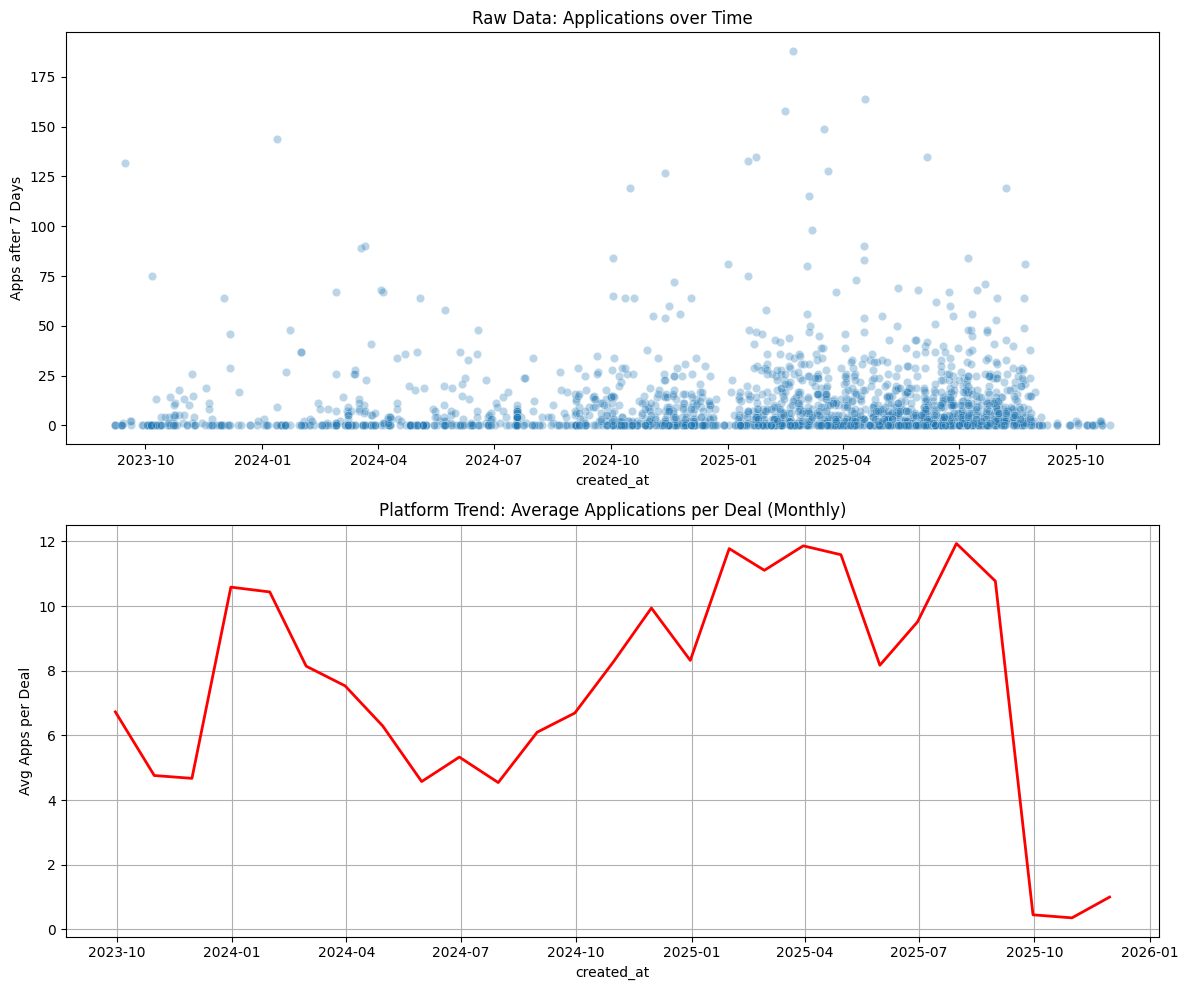

Correlation between Time and Application Count: 0.0816
Correlation between Monthly Deal Volume and mean of apps_after_7_days: 0.6773


In [23]:
visualise_var_over_time('apps_after_7_days', 'mean')

- Sum of 'applications after 7 days' per deal over time

/var/folders/j6/_nwsrmhx5w1fj_nrxmrss8180000gq/T/ipykernel_60383/1665239933.py:36: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_trend = og_df.set_index('created_at').resample('M')[y_variable].agg([agg_type, 'count'])


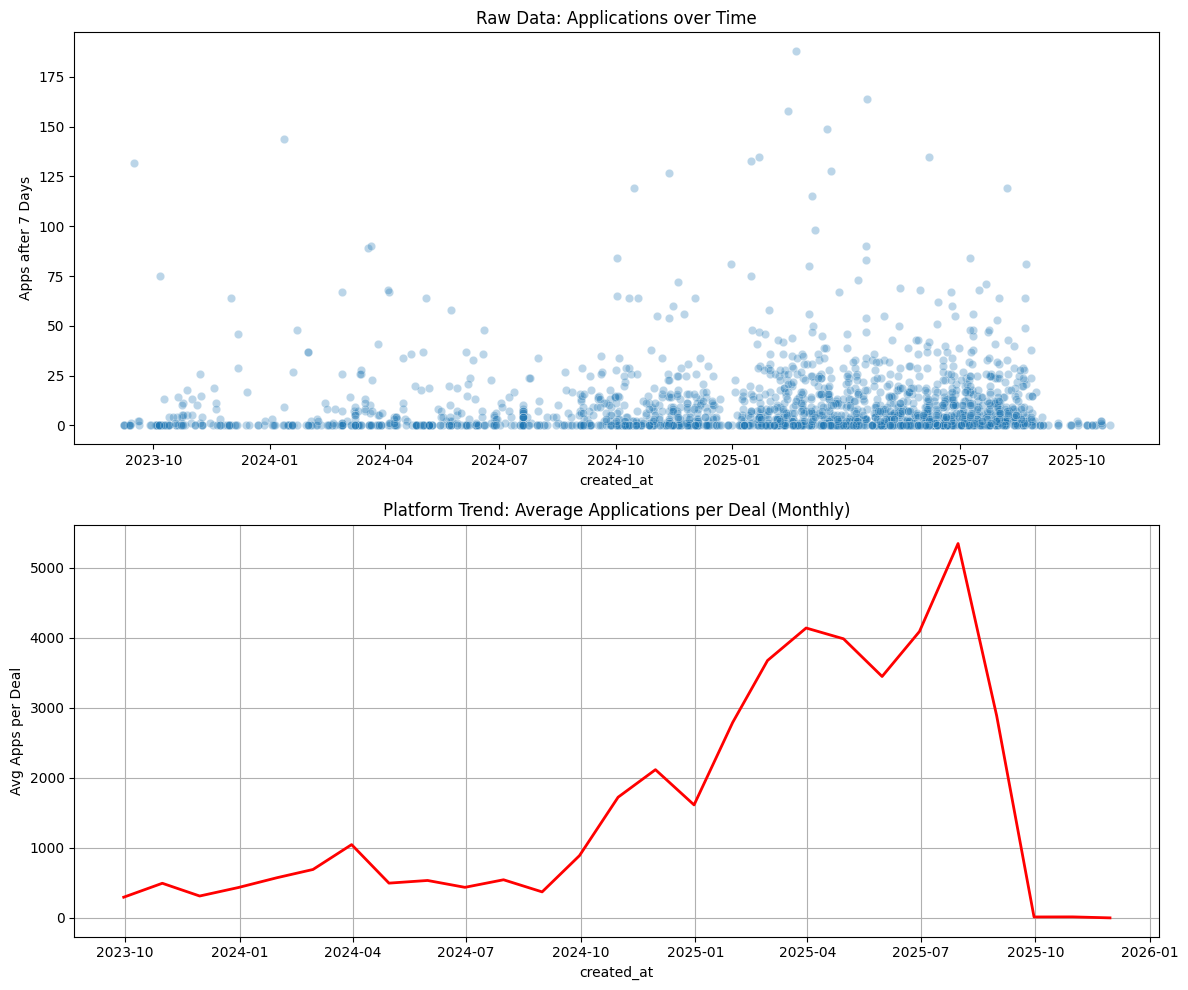

Correlation between Time and Application Count: 0.0816
Correlation between Monthly Deal Volume and sum of apps_after_7_days: 0.9733


In [21]:
visualise_var_over_time('apps_after_7_days', 'sum')

In [29]:
subset_final_df

,applicants_applications_count,content_types,deal_id,main_image,min_social_media_followers,deal_tags,live_since,created_at,updated_at,deleted_at,...,top_k_tokens,constrained_tokens,sorted_tokens,sorted_logits,mean_rating,mode_rating,scale_size,entropy,normalized_entropy,first_content_type
0,39,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",0196edc7-e6a8-00c8-6ff5-ea60fa3f2895,uploads/deals/0196edc7-5969-ffff-6700-7ae699b8...,2500,None,2025-05-20 15:21:28.249567,2025-05-20 13:00:23.080212,2025-10-28 10:55:34.719187,NaT,...,"[[5, 4, **, âģ, ï¸ı, 3, â, Ġ**, 6, âĳ, âĺħâĺħ,...","[1, 2, 3, 4, 5]","[1, 2, 3, 4, 5]","[[16.677732467651367, 15.764606475830078, 21.4...",4.975333,5.0,5,0.115684,0.071878,Activities
5,0,"[{'id': 21, 'name': 'Fashion', 'slug': 'Dress'}]",019689e5-f489-00c8-8c26-06b3ea0961a5,uploads/deals/019689e5-f54b-ffff-dbed-637e9d2a...,5000,None,2023-11-28 14:59:51.626780,2023-11-28 14:59:51.626780,2025-05-01 03:31:11.600095,NaT,...,"[[2, 3, 1, 4, 5, ï¼Ĵ, âĤĤ, 6, 0, **, 8, 7, Â²,...","[1, 2, 3, 4, 5]","[1, 2, 3, 4, 5]","[[32.36299514770508, 53.47678756713867, 41.655...",2.000007,2.0,5,0.000094,0.000059,Fashion
10,23,"[{'id': 29, 'name': 'UGC', 'slug': 'Film-Strip'}]",019689e2-bfb5-00c8-6485-23352d64b0e5,uploads/deals/019689e2-c06c-ffff-baf0-c7e9decd...,5000,None,2025-03-04 11:46:18.176627,2025-03-04 11:46:18.176627,2025-05-01 03:27:41.316646,NaT,...,"[[4, 3, 5, ï¼Ķ, 2, **, ï¸ı, âģ, 6, Ġ**, 1, Û, ...","[1, 2, 3, 4, 5]","[1, 2, 3, 4, 5]","[[18.20315933227539, 23.730012893676758, 34.79...",3.999999,4.0,5,0.000012,0.000008,UGC
15,43,"[{'id': 21, 'name': 'Fashion', 'slug': 'Dress'}]",019689e3-d7a5-00c8-f5a8-6bfe51a21cd6,uploads/deals/019689e3-d86f-ffff-a03e-d38765a0...,2500,None,2025-04-17 09:50:45.518632,2025-04-17 09:50:45.518632,2025-06-08 09:05:21.413273,NaT,...,"[[4, 3, 5, 2, ï¼Ķ, **, âģ, 6, ï¸ı, 8, 7, Ġ**, ...","[1, 2, 3, 4, 5]","[1, 2, 3, 4, 5]","[[18.516578674316406, 24.72058868408203, 35.33...",4.000000,4.0,5,0.000004,0.000003,Fashion
20,13,"[{'id': 19, 'name': 'Sport', 'slug': 'Soccer-B...",019689e5-7dd0-00c8-615b-7750a8fec2f3,uploads/deals/019689e5-7f9d-ffff-5b6d-a335c1ce...,2500,None,2025-02-10 18:19:51.240203,2025-02-10 18:19:51.240203,2025-10-28 10:51:05.147656,NaT,...,"[[4, 3, 2, 5, **, ï¼Ķ, 6, 1, ï¸ı, Â³, 8, Ġ**, ...","[1, 2, 3, 4, 5]","[1, 2, 3, 4, 5]","[[19.365690231323242, 29.54205322265625, 44.74...",3.883868,4.0,5,0.359148,0.223151,Sport
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4975,23,"[{'id': 40, 'name': 'Drinks', 'slug': 'Champag...",019689e3-7bb6-00c8-8080-218aa047dc6f,uploads/deals/019689e3-7ca8-ffff-44d8-cd38201c...,5000,None,2024-12-09 13:41:12.466233,2024-12-09 13:41:12.466233,2025-08-25 04:00:12.963454,NaT,...,"[[3, 4, 2, 5, ï¼ĵ, 1, **, Â³, 6, ï¸ı, Ġ**, Û, ...","[1, 2, 3, 4, 5]","[1, 2, 3, 4, 5]","[[21.27135467529297, 36.82992172241211, 49.041...",3.000011,3.0,5,0.000264,0.000164,Drinks
4980,5,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",019689e4-8421-00c8-1140-884d776fa14b,uploads/deals/019689e4-8505-ffff-b8ab-5f54ac17...,5000,None,2025-01-09 12:18:16.852975,2025-01-09 12:18:16.852975,2025-10-28 10:51:47.589008,NaT,...,"[[3, 4, 2, 5, **, ï¸ı, Â³, 1, ï¼Ķ, Ġ**, Û, 6, ...","[1, 2, 3, 4, 5]","[1, 2, 3, 4, 5]","[[20.76657485961914, 31.85316276550293, 44.331...",3.348762,3.0,5,0.646712,0.401825,Activities
4985,7,"[{'id': 23, 'name': 'Food', 'slug': 'Pizza'}, ...",0197b09a-aee0-00c8-2d24-860ed0024e48,uploads/deals/0197b092-b9e6-ffff-6edb-7e68e0fa...,1500,None,2025-06-27 12:12:09.463092,2025-06-27 08:56:56.800200,2025-10-28 11:04:09.701711,NaT,...,"[[5, 4, 3, **, âģ, ï¸ı, 6, â, Ġ**, 2, 1, âĳ, 0...","[1, 2, 3, 4, 5]","[1, 2, 3, 4, 5]","[[17.83180809020996, 17.90509033203125, 24.202...",4.835349,5.0,5,0.447304,0.277925,Food
4990,0,"[{'id': 29, 'name': 'UGC', 'slug': 'Film-Strip...",019689e2-d879-00c8-0783-bbe41f1a45ac,uploads/deals/019689e2-d940-ffff-9b7a-7bf93905...,5000,None,2025-03-04 16:58:29.302085,2025-03-04 16:58:29.302085,2025-05-01 03:27:

In [30]:
subset_final_df = final_df[final_df.prompt_id == 'd6ac463714']

# 1. Ensure datetime format
subset_final_df['created_at'] = pd.to_datetime(subset_final_df['created_at'])

# 2. Extract a numeric 'Time' feature for correlation (e.g., Days since start)
# We subtract the minimum date to get a "Day 0", "Day 1"... counter
start_date = subset_final_df['created_at'].min()
subset_final_df['days_since_start'] = (subset_final_df['created_at'] - start_date).dt.days


/var/folders/j6/_nwsrmhx5w1fj_nrxmrss8180000gq/T/ipykernel_60383/3280417043.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_final_df['created_at'] = pd.to_datetime(subset_final_df['created_at'])
/var/folders/j6/_nwsrmhx5w1fj_nrxmrss8180000gq/T/ipykernel_60383/3280417043.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_final_df['days_since_start'] = (subset_final_df['created_at'] - start_date).dt.days


Correlation between Time and Quality: 0.1116


/var/folders/j6/_nwsrmhx5w1fj_nrxmrss8180000gq/T/ipykernel_60383/324137567.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_quality = subset_final_df.set_index('created_at').resample('M')['mean_rating'].mean()


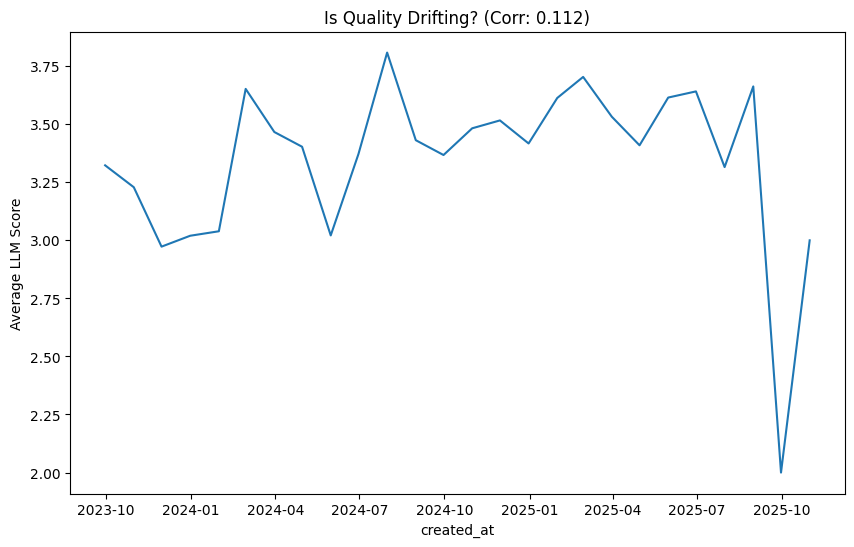

In [33]:
# 1. Check if Quality correlates with Time
# We use the 'days_since_start' we created earlier
quality_time_corr = subset_final_df[['days_since_start', 'mean_rating']].corr().iloc[0, 1]

print(f"Correlation between Time and Quality: {quality_time_corr:.4f}")

# 2. Visualize the drift
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
# Plot monthly average quality to reduce noise
monthly_quality = subset_final_df.set_index('created_at').resample('M')['mean_rating'].mean()

sns.lineplot(x=monthly_quality.index, y=monthly_quality.values)
plt.title(f"Is Quality Drifting? (Corr: {quality_time_corr:.3f})")
plt.ylabel("Average LLM Score")
plt.show()

## General

- Deals with zero applications

In [ ]:
og_df_zero_apps = og_df[og_df.applicants_applications_count == 0]
og_df_zero_apps

,applicants_applications_count,content_types,deal_id,main_image,min_social_media_followers,deal_tags,live_since,created_at,updated_at,deleted_at,...,legacy_id,tags,gender,featured_image,company_id,test_nr_of_apps,update_at_date,diff,apps_after_7_days,apps_after_7_days_OLD
1,0,"[{'id': 21, 'name': 'Fashion', 'slug': 'Dress'}]",019689e5-f489-00c8-8c26-06b3ea0961a5,uploads/deals/019689e5-f54b-ffff-dbed-637e9d2a...,5000,None,2023-11-28 14:59:51.626780,2023-11-28 14:59:51.626780,2025-05-01 03:31:11.600095,NaT,...,487.0,None,None,None,None,0,2025-05-01,0,0,0.0
7,0,"[{'id': 19, 'name': 'Sport', 'slug': 'Soccer-B...",019689e4-306b-00c8-d98c-70210470c288,uploads/deals/019689e4-3146-ffff-e4a6-efb122b1...,2500,None,2024-12-21 13:36:47.610355,2024-12-21 13:36:47.610355,2025-05-01 03:29:15.743063,NaT,...,2587.0,None,None,None,None,0,2025-05-01,0,0,0.0
20,0,"[{'id': 21, 'name': 'Fashion', 'slug': 'Dress'}]",0196cf30-3d9e-00c8-45de-a6091919cc67,,1500,None,NaT,2025-05-14 14:26:07.390204,2025-05-14 14:38:34.607315,2025-05-15 09:33:30.588079+00:00,...,NaN,None,None,None,None,0,2025-05-14,0,0,NaN
22,0,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",019689e2-4ed5-00c8-4120-a08641f9f6f7,uploads/deals/019689e2-4ff4-ffff-5f8b-033c32b8...,5000,None,2024-05-02 09:27:34.909380,2024-05-02 09:27:34.909380,2025-05-01 03:27:12.709921,NaT,...,1068.0,None,None,None,None,0,2025-05-01,0,0,4.0
23,0,"[{'id': 21, 'name': 'Fashion', 'slug': 'Dress'}]",0196cf35-c5d6-00c8-4d97-bbfef60b2cf5,,2500,None,NaT,2025-05-14 14:32:09.942486,2025-05-14 14:32:15.868080,2025-05-14 14:35:11.325650+00:00,...,NaN,None,None,None,None,0,2025-05-14,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5041,0,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",019689e4-8d77-00c8-af2c-88afecf6d330,uploads/deals/019689e4-8e9b-ffff-f2dc-de9dc691...,2500,None,2025-02-05 10:50:49.679167,2025-02-05 10:50:49.679167,2025-10-28 10:51:10.763570,NaT,...,3155.0,None,None,None,0199f1b1-a870-015e-9154-4fe289974050,0,2025-10-28,0,0,0.0
5068,0,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",019689e4-9589-00c8-7dcb-d0bd27e9de7d,uploads/deals/019689e4-96ac-ffff-a035-6766138f...,50000,None,2025-04-27 09:08:03.830735,2025-04-27 09:08:03.830735,2025-10-28 10:50:03.356636,NaT,...,4362.0,None,None,None,0199f1a2-caa1-015e-b4db-2edf3b482672,0,2025-10-28,0,0,3.0
5098,0,"[{'id': 39, 'name': 'Experiences', 'slug': 'Te...",019689e4-a9d4-00c8-6d70-59ec50167ab7,uploads/deals/019689e4-aa38-ffff-e781-3a523780...,5000,None,2024-03-15 13:45:49.561715,2024-03-15 13:45:49.561715,2025-10-28 10:54:48.369215,NaT,...,805.0,None,None,None,0199f1cd-8862-015e-ca76-0be502d21b6a,0,2025-10-28,0,0,0.0
5108,0,"[{'id': 23, 'name': 'Food', 'slug': 'Pizza'}]",0198324e-635d-00c8-7d1d-bbb0b902b0d9,,10000,None,NaT,2025-07-22 13:24:14.813323,2025-10-28 11:04:12.121141,NaT,...,NaN,None,None,None,0199f18e-af17-015e-23aa-c780e5c4a2b8,0,2025-10-28,0,0,NaN


- Deals with positive number of applications but no applications after 7 days

In [ ]:
og_df[(og_df['apps_after_7_days'] == 0) & (og_df['applicants_applications_count'] > 0)]

,applicants_applications_count,content_types,deal_id,main_image,min_social_media_followers,deal_tags,live_since,created_at,updated_at,deleted_at,...,legacy_id,tags,gender,featured_image,company_id,test_nr_of_apps,update_at_date,diff,apps_after_7_days,apps_after_7_days_OLD
24,65,"[{'id': 23, 'name': 'Food', 'slug': 'Pizza'}, ...",019689e5-c8c2-00c8-79f3-9992362edeea,uploads/deals/019689e5-c976-ffff-edd8-529b3e62...,5000,None,NaT,2023-11-22 12:13:25.712323,2025-05-01 03:31:00.674606,2024-02-10 14:35:49.163784+00:00,...,468.0,None,None,None,None,65,2025-05-01,0,0,NaN
25,56,"[{'id': 23, 'name': 'Food', 'slug': 'Pizza'}]",019689e4-bde0-00c8-dcce-bb7de653145b,uploads/deals/019689e4-be81-ffff-4174-cd8a5c2d...,10000,None,2025-01-13 15:37:11.226833,2025-01-13 15:37:11.226833,2025-05-22 04:00:16.868866,NaT,...,2890.0,None,None,None,None,56,2025-05-22,0,0,0.0
31,18,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",0196f22e-9224-00c8-1f18-378560b58a42,uploads/deals/0196f22a-eae6-ffff-e2f6-8a112033...,1500,None,2025-05-21 09:31:00.752564,2025-05-21 09:31:00.516748,2025-10-28 10:52:44.677317,NaT,...,NaN,None,None,None,0199f1d9-ba9c-015e-98dd-31cc262c0e04,18,2025-10-28,0,0,0.0
33,6,"[{'id': 23, 'name': 'Food', 'slug': 'Pizza'}]",019689e3-770b-00c8-d2ee-83252084a97a,uploads/deals/019689e3-77aa-ffff-9af7-e4cde670...,2500,None,NaT,2024-02-16 13:13:22.821687,2025-05-01 03:28:28.371244,2024-02-24 14:08:58.711124+00:00,...,660.0,None,None,None,None,6,2025-05-01,0,0,NaN
44,148,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",019689e3-287d-00c8-258d-b4e8df65b7a5,uploads/deals/019689e3-294c-ffff-313b-5c2680e5...,5000,None,2023-09-28 12:34:50.532202,2023-09-28 12:34:50.532202,2025-10-28 10:56:13.372705,NaT,...,184.0,None,None,None,0199f1d2-2345-015e-d386-0d22efe5edcf,148,2025-10-28,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4971,3,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",0196d4a5-62a4-00c8-afe1-0e592c281122,uploads/deals/0196d4a4-a3e1-ffff-f2c5-d2aebc1c...,10000,None,2025-05-15 15:52:10.852458,2025-05-15 15:52:10.660506,2025-06-15 21:59:22.317427,NaT,...,NaN,None,None,None,None,3,2025-06-15,0,0,6.0
4993,1,"[{'id': 29, 'name': 'UGC', 'slug': 'Film-Strip...",0196ceae-4334-00c8-65d6-7fb556b9ba6f,uploads/deals/0196ceae-1f69-ffff-955d-61eb09b2...,5000,None,2025-05-14 12:04:09.257984,2025-05-14 12:04:09.140652,2025-05-14 12:04:09.258113,NaT,...,NaN,None,None,None,None,1,2025-05-14,0,0,37.0
5006,6,"[{'id': 25, 'name': 'Cooking', 'slug': 'Cookin...",019689e4-8482-00c8-60fa-3cb52ac85ff5,uploads/deals/019689e4-8597-ffff-9779-60501bb9...,2500,None,2025-05-20 11:35:10.937802,2025-04-25 14:03:19.480448,2025-10-28 10:49:41.201605,NaT,...,4352.0,None,None,None,0199f19e-56a2-015e-a4aa-5d54b2c701bb,6,2025-10-28,0,0,13.0
5019,31,"[{'id': 39, 'name': 'Experiences', 'slug': 'Te...",019689e3-2d2a-00c8-8b96-27c693c7ab51,uploads/deals/019689e3-2d91-ffff-6b6c-b8dfc7c8...,5000,None,2024-02-06 10:29:13.139738,2024-02-06 10:29:13.139738,2025-05-01 03:28:09.341890,NaT,...,630.0,None,None,None,None,31,2025-05-01,0,0,28.0


- Duplicate deals

In [ ]:
text_stats = og_df.groupby('partner_id')['apps_after_7_days'].agg(['count', 'mean', 'var', 'std'])
text_stats

,count,mean,var,std
partner_id,,,,
1,6,0.000000,0.000000,0.000000
2,1,0.000000,NaN,NaN
3,6,0.166667,0.166667,0.408248
4,13,18.307692,1863.730769,43.170948
5,2,0.000000,0.000000,0.000000
...,...,...,...,...
3460,1,0.000000,NaN,NaN
3468,1,0.000000,NaN,NaN
3471,1,0.000000,NaN,NaN


In [ ]:
# 1. Group by identical deal text
# We calculate count (to find dupes), mean, and variance for each unique text
text_stats = og_df.groupby('deal_text')['apps_after_7_days'].agg(['count', 'mean', 'var', 'std'])

# 2. Filter: We only care about texts that were posted more than once
# We also drop NaNs in variance (which happen if count < 2)
duplicates = text_stats[text_stats['count'] > 1].dropna()

print(f"Found {len(duplicates)} unique texts that were posted multiple times.")
print(f"Total observations involved in duplicates: {duplicates['count'].sum()}")

# 3. Calculate the "Pure Error" vs "Total Variance"
# Pure Error = The average variance *within* these identical groups
pure_error_variance = duplicates['var'].mean()

# Total Variance = The variance of the entire dataset (ignoring text identity)
total_variance = og_df['apps_after_7_days'].var()

# 4. The "Unexplainable" Ratio
noise_ratio = pure_error_variance / total_variance

print(f"\n--- Variance Analysis ---")
print(f"Total Dataset Variance:   {total_variance:.2f}")
print(f"Variance within Reposts:  {pure_error_variance:.2f} (Pure Error)")
print(f"Noise Ratio:              {noise_ratio:.2%}")

# 5. Interpretation
if noise_ratio > 0.5:
    print("\n⚠️ CRITICAL: Over 50% of the variation in applications has nothing to do with the text.")
    print("Even if you trained a perfect AI, it could only explain <50% of the results.")
else:
    print(f"\n✅ Good News: Only {noise_ratio:.1%} of variance is random noise.")
    print("There is still plenty of signal for the model to learn.")

Found 293 unique texts that were posted multiple times.
Total observations involved in duplicates: 788

--- Variance Analysis ---
Total Dataset Variance:   268.49
Variance within Reposts:  131.02 (Pure Error)
Noise Ratio:              48.80%

✅ Good News: Only 48.8% of variance is random noise.
There is still plenty of signal for the model to learn.


- Partners with many deals

In [ ]:
partner_count = og_df.partner_id.value_counts()
partner_count

# og_df = pd.merge(og_df, partner_count, on = 'partner_id')
# partner_count


In [ ]:
# Proportion of observations that come from partners that have more than 10 total deals

partner_count[partner_count > 10].sum() / partner_count.sum()

np.float64(0.21829924650161464)